# Quantum Broadcasting Protocol

Unified implementation notebook supporting three execution modes:

| Mode | Backend | Description |
|------|---------|-------------|
| **Exact** | `ExactBackend` | Full density-matrix simulation (no sampling noise) |
| **Sampling** | `SamplingBackend` | Monte Carlo Pauli-trajectory simulation |
| **Hardware** | `HardwareBackend` | Run on IBM Quantum hardware via `qiskit-ibm-runtime` |

Select the mode in **Cell 2** and run all cells.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from broadcasting.protocol import ProtocolConfig, BroadcastResult
from broadcasting.backend import ExactBackend, SamplingBackend, HardwareBackend
from broadcasting.results import save_run, load_run, list_runs
from broadcasting.plotting import (
    plot_fidelity_vs_noise,
    plot_fidelity_vs_delay,
    plot_3d_fidelity,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120})

## 1. Configuration

Set protocol parameters and choose a mode.

In [4]:
# ---------- Choose mode ----------
MODE = "sampling"  # "exact" | "sampling" | "hardware"

# ---------- Protocol parameters ----------
M = 1                          # senders
N = 2                          # receivers
alpha = 1.0 / np.sqrt(2)  # input-state coefficient
thetas = np.random.rand(M) * 2 * np.pi  # sender phase angles
outcomes = [0] * M             # Alice measurement outcomes
use_qec = True                # enable [[5,1,3]] QEC

# Noise sweep
p_list = np.linspace(0, 1, 50).tolist()

# Sampling-mode options
n_samples = 1000
seed = 42

# Hardware-mode options (fill in when MODE="hardware")
IBM_CHANNEL = "ibm_quantum"      # or "ibm_cloud"
IBM_INSTANCE = "ibm-q/open/main"
IBM_BACKEND  = "ibm_brisbane"    # can check least busy with service.least_busy(simulator=False, operational=True)
SHOTS = 4096

print(f"Mode: {MODE}  |  M={M}, N={N}, QEC={use_qec}  |  {len(p_list)} noise values")

Mode: sampling  |  M=1, N=2, QEC=True  |  50 noise values


## 2. Run Experiment

In [5]:
config = ProtocolConfig(
    M=M, N=N, alpha=alpha, thetas=thetas,
    p_list=p_list, use_qec=use_qec,
    outcomes_list=outcomes,
    n_samples=n_samples if MODE == "sampling" else None,
    seed=seed,
)

if MODE == "exact":
    backend = ExactBackend()
elif MODE == "sampling":
    backend = SamplingBackend(n_samples=n_samples, seed=seed)
elif MODE == "hardware":
    from qiskit_ibm_runtime import QiskitRuntimeService
    service = QiskitRuntimeService(channel=IBM_CHANNEL, instance=IBM_INSTANCE)
    backend = HardwareBackend(service=service, backend_name=IBM_BACKEND, shots=SHOTS)
else:
    raise ValueError(f"Unknown mode: {MODE}")

result = backend.run(config)
print(f"Fidelities shape: {np.array(result.fidelities).shape}")
print(f"Mode recorded:    {result.metadata.get('mode')}")

Fidelities shape: (50, 2)
Mode recorded:    sampled (1000 trajectories)


## 3. Save Results

In [6]:
out_path = save_run(result, config)
print(f"Saved to {out_path}")

Saved to results\run_20260409_142625.json


## 4. Plot: Fidelity vs Noise

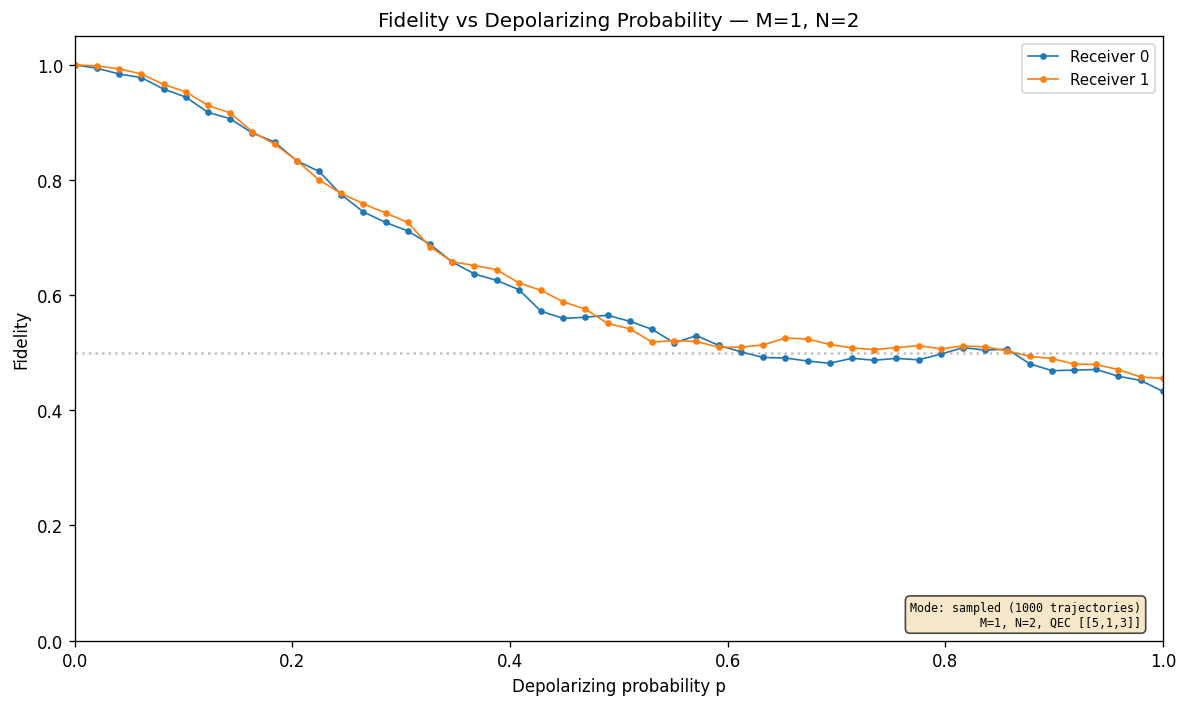

In [7]:
fids = np.array(result.fidelities)  # shape (len(p_list), N)
fidelity_arrays = {f"Receiver {i}": fids[:, i] for i in range(N)}

plot_fidelity_vs_noise(
    np.array(p_list),
    fidelity_arrays,
    mode_label=result.metadata.get("mode", MODE),
    protocol_info={"M": M, "N": N, "use_qec": use_qec},
    title=f"Fidelity vs Depolarizing Probability — M={M}, N={N}",
);

## 5. Compare Exact vs Sampling (optional)

Run both backends and overlay the curves.

In [ ]:
# Uncomment to run the comparison
# exact_result   = ExactBackend().run(config)
# sampling_result = SamplingBackend(n_samples=5000, seed=0).run(
#     config._replace(use_qec=True) if hasattr(config, '_replace')
#     else ProtocolConfig(**{**config.__dict__, 'use_qec': True})
# )
#
# fig, ax = plt.subplots(figsize=(10, 6))
# p_arr = np.array(p_list)
# exact_fids = np.array(exact_result.fidelities)
# samp_fids  = np.array(sampling_result.fidelities)
# for i in range(N):
#     ax.plot(p_arr, exact_fids[:, i], '-', label=f'Exact R{i}')
#     ax.plot(p_arr, samp_fids[:, i], '--', label=f'Sampling R{i}')
# ax.set_xlabel('p'); ax.set_ylabel('Fidelity')
# ax.legend(); ax.set_title('Exact vs Sampling comparison')
# plt.tight_layout(); plt.show()

## 6. Load & Inspect Previous Runs

In [ ]:
runs = list_runs()
print(f"{len(runs)} saved runs:")
for r in runs[-5:]:
    print(f"  {r.name}")